# 현제 전력소비 현황 분석 및 전력공급사 변경시의 시뮬레이션

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 현 상황 분석 : 원일

In [3]:
df = pd.read_csv("electricity_usage.csv")

In [4]:
df

,연/월,전기사용량,간사이전력 종량전등A
0,25년 3월,76,1962
1,25년 4월,132,3536
2,25년 5월,155,4504
3,25년 6월,133,3804
4,25년 7월,216,6446
5,25년 8월,41,1165
6,25년 9월,76,1990
7,25년 10월,117,3022
8,25년 11월,154,4417
9,25년 12월,187,5468


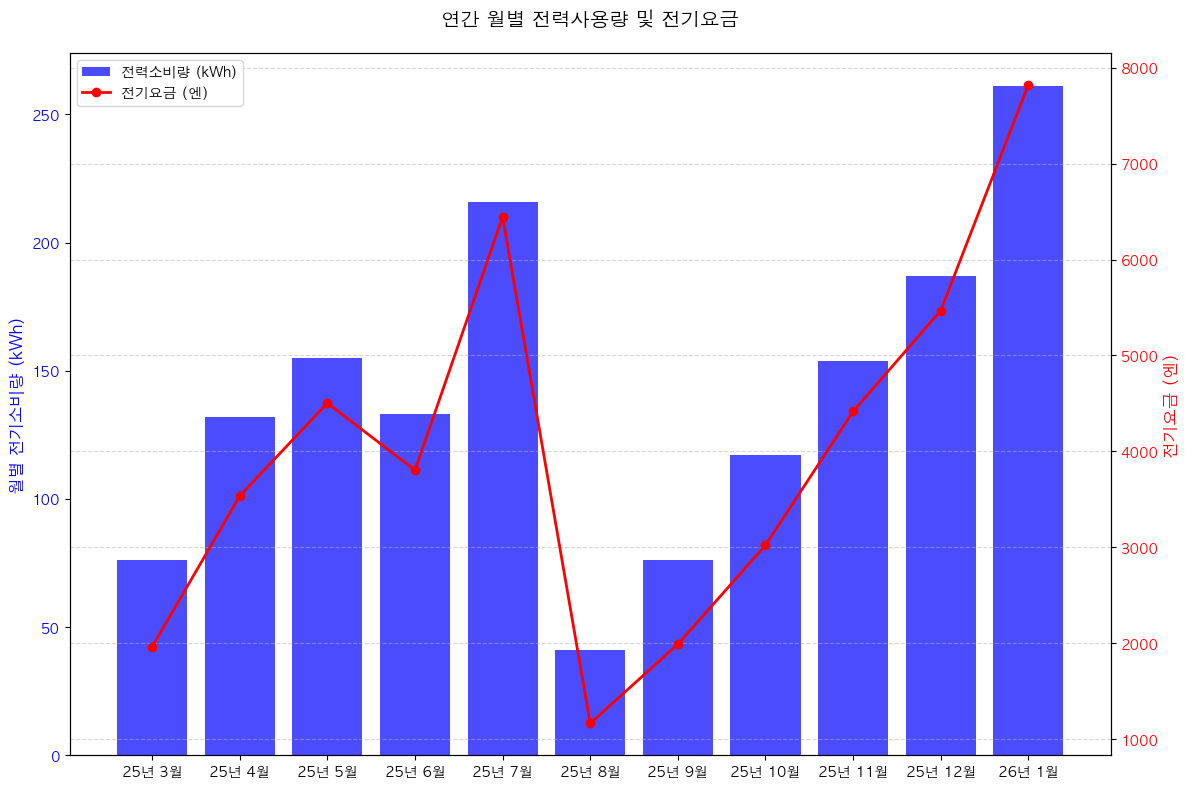

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 8))
plt.title("연간 월별 전력사용량 및 전기요금", fontsize=14, pad=20)

bars = ax1.bar(df.index, df["전기사용량"], color="blue", alpha=0.7, label="전력소비량 (kWh)")
ax1.set_ylabel('월별 전기소비량 (kWh)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
line = ax2.plot(df.index, df["간사이전력 종량전등A"], color="red", marker='o', linewidth=2, label="전기요금 (엔)")
ax2.set_ylabel('전기요금 (엔)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.xticks(df.index, df["연/월"], rotation=90)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
df_time = pd.read_csv("electricity_usage_per_time.csv")

In [7]:
df_time

,시간대,25년 3월,25년 4월,25년 5월,25년 6월,25년 7월,25년 8월,25년 9월,25년 10월,25년 11월,25년 12월,26년 1월
0,0:00,1.3,1.7,2.8,4.6,11.0,1.2,3.1,3.2,2.8,4.4,9.8
1,1:00,1.5,2.0,3.3,4.4,9.6,1.5,2.3,3.5,3.7,5.3,8.4
2,2:00,3.4,1.6,3.2,5.0,9.3,1.7,2.5,2.3,4.1,6.1,10.3
3,3:00,10.7,5.4,8.4,6.2,11.0,1.0,3.3,2.8,6.3,16.0,26.4
4,4:00,28.1,40.2,43.4,30.8,48.1,3.9,12.5,29.0,41.9,47.8,56.7
5,5:00,18.9,50.7,56.1,44.0,40.8,5.3,14.2,41.3,59.8,53.4,65.2
6,6:00,0.6,0.8,1.8,1.9,4.5,1.5,2.5,1.7,2.2,4.5,6.4
7,7:00,0.1,1.2,1.4,1.7,4.7,1.5,2.0,2.2,2.0,4.2,7.4
8,8:00,0.8,1.7,1.4,1.9,4.9,1.5,1.5,2.0,1.9,3.7,6.2
9,9:00,0.1,1.0,2.0,2.1,4.5,1.9,1.9,1.8,2.3,2.2,4.9


In [8]:
df_time['25년 봄'] = (df_time["25년 4월"] + df_time["25년 5월"]) / 2
df_time['25년 여름'] = (df_time["25년 6월"] + df_time["25년 7월"]) / 2
df_time['25년 가을'] = (df_time["25년 10월"] + df_time["25년 11월"]) / 2
df_time['26년 겨울'] = (df_time["25년 12월"] + df_time["26년 1월"]) / 2

df_seasonal = df_time[["시간대", "25년 봄", "25년 여름", "25년 가을", "26년 겨울"]].copy()
df_time.drop(columns=["25년 봄", "25년 여름", "25년 가을", "26년 겨울"], inplace=True)

In [9]:
df_temporal_melted = df_time.melt(id_vars='시간대', var_name='월', value_name="사용량")
df_seasonal_melted = df_seasonal.melt(id_vars='시간대', var_name='계절', value_name='평균사용량')

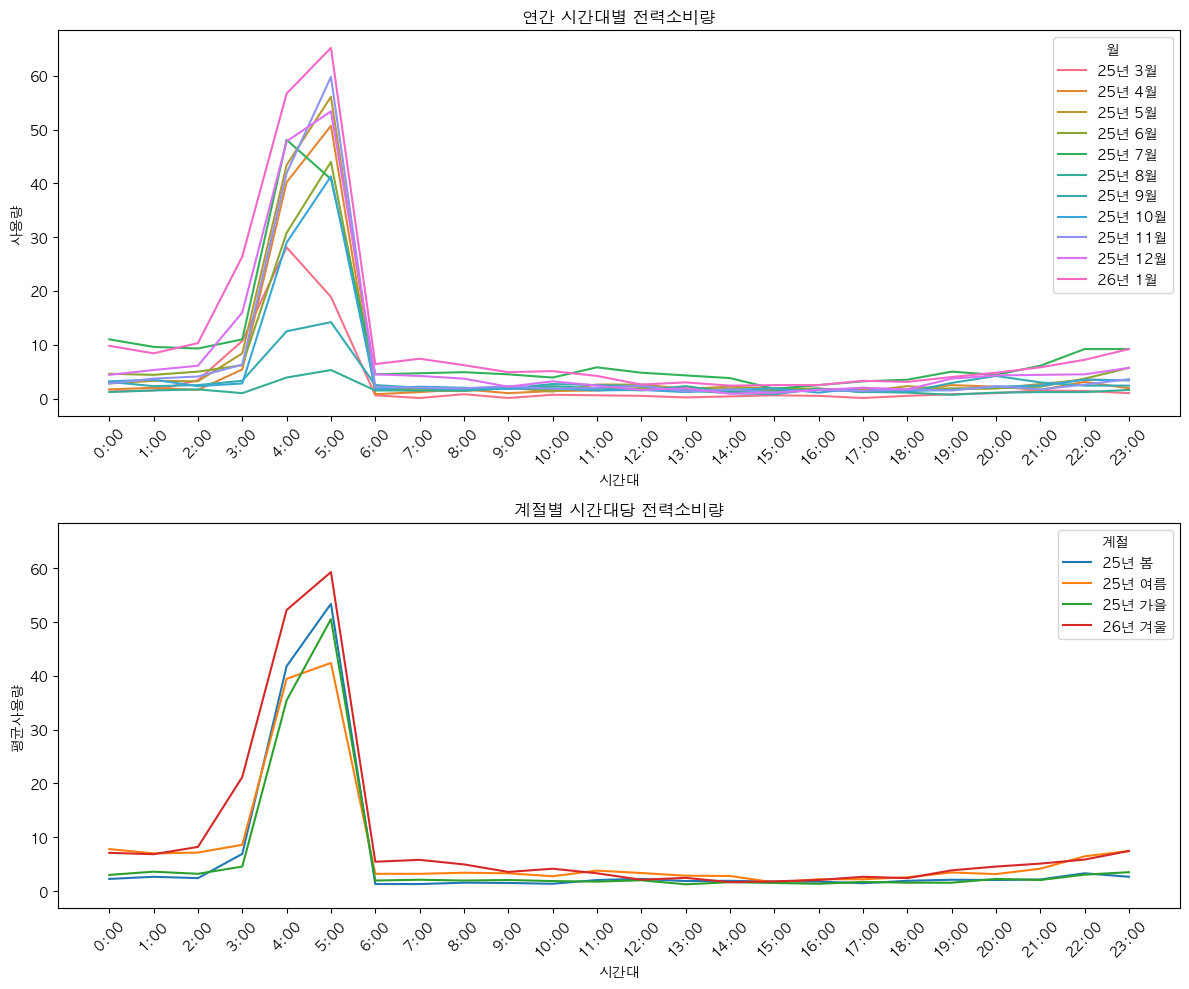

In [10]:
fig, axes = plt.subplots(2, 1, figsize = (12, 10), sharey=True)

sns.lineplot(data=df_temporal_melted, x='시간대', y='사용량', hue='월', ax=axes[0])
axes[0].set_title("연간 시간대별 전력소비량")
axes[0].tick_params(axis='x', labelrotation=45)

sns.lineplot(data=df_seasonal_melted, x='시간대', y='평균사용량', hue='계절', ax=axes[1])
axes[1].set_title("계절별 시간대당 전력소비량")
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

위 자료를 시각화하였을 때 오전 3시에서 오전 5시간에 전기 사용량이 가장 많은 것으로 나타났다. 그 이유는 심야 온수 급탕기 사용으로 추정된다. 또한 계절별로 전력소비량을 시각화 하였을 때 겨울에 전기사용량이 확연히 증가하는 것을 확인할 수 있다. 이는 겨울에는 히터를 사용하기 때문인데, 여름에는 선풍기를 사용하여 전력소비량을 줄일 수 있으나 겨울에는 이와 같은 것이 불가능하기 때문이다.

아래 그래프는 방학으로 인해 귀국하였을 때인 3월, 8월, 9월을 제외한 수치이다. 실거주 한 기간만의 전기 사용량을 시각화하였을 때 뚜렷한 경향성이 나타났다. 여름과 겨울의 전력사용량이 봄, 가을의 전기 사용량보다 확연히 높았다. 특이사항으로 여름에는 선풍기를 사용하지 않고 에어컨 만을 사용해 냉방을 했으나 그럼에도 불구하고 겨울보다는 전기 사용량이 낮았다. 이로 인해 난방이 냉방보다 전력 사용량이 높음을 알 수 있다. 또한, 온수 급탕기가 가동되는 오전 3시 - 오전 5시 구간에서는 오히려 가장 전력 사용량이 낮았다. 마지막으로 전체적으로 15시 이후에 전기 사용량이 증가하기 시작하여 오전 2시까지 서서히 증가한다. 오전 3시에 급증하여 오전 5시에 최고점에 도달하며 오전 6시까지 급락한다. 오전 7시부터 오후 3시까지는 전기 사용량이 거의 없다.

In [11]:
df_temporal_no_peak = df_time.drop([3, 4, 5])
df_seasonal_no_peak = df_seasonal.drop([3, 4, 5])

In [12]:
df_temporal_no_peak_melted = df_temporal_no_peak.melt(id_vars='시간대', var_name='월', value_name="사용량")
df_seasonal_no_peak_melted = df_seasonal_no_peak.melt(id_vars='시간대', var_name='계절', value_name='평균사용량')

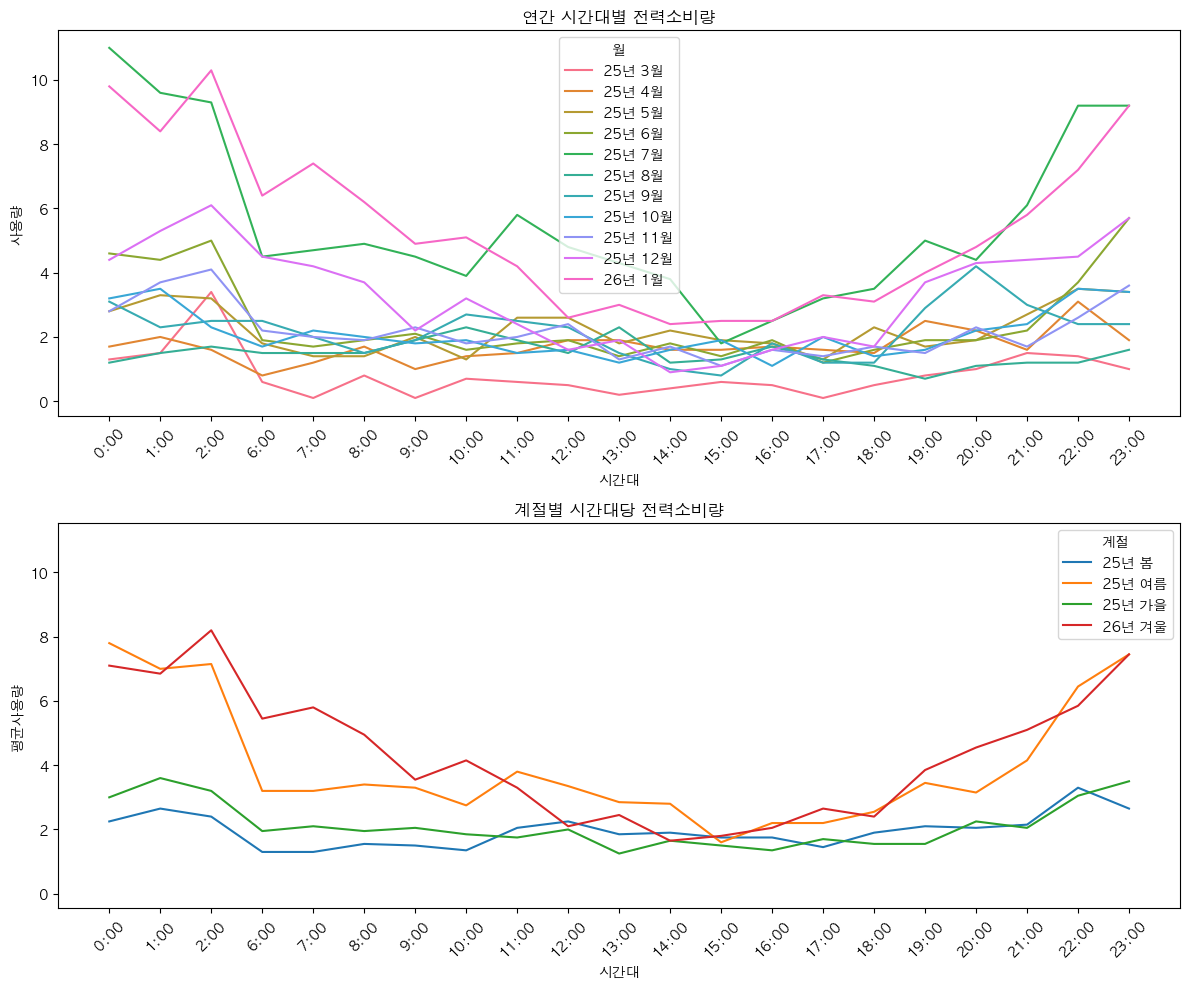

In [13]:
fig, axes = plt.subplots(2, 1, figsize = (12, 10), sharey=True)

sns.lineplot(data=df_temporal_no_peak_melted, x='시간대', y='사용량', hue='월', ax=axes[0])
axes[0].set_title("연간 시간대별 전력소비량")
axes[0].tick_params(axis='x', labelrotation=45)

sns.lineplot(data=df_seasonal_no_peak_melted, x='시간대', y='평균사용량', hue='계절', ax=axes[1])
axes[1].set_title("계절별 시간대당 전력소비량")
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

전기 사용량이 가장 많은 오전 3시 - 오전 5시를 제외한 그래프에서는 심야-아침 시간대를 제외한 시간대의 전력소비량이 대동소이한 것으로 나타났다.

## 결론
1. 오전 3시 - 오전 5시 구간에 많은 전력이 소비된다.
2. 여름과 겨울에 비교적 전력 사용량이 많다.
3. 여름과 겨울에도 심야 - 아침 시간대를 제외하면 전력소비량의 차이가 크지는 않다.

# 전력공급사 변경시 전기요금 변동 시뮬레이션

In [14]:
def green_octopus(row):
    days_map = {
        '1월': 31, '2월': 28, '3월': 31, '4월': 30, '5월': 31, '6월': 30,
        '7월': 31, '8월': 31, '9월': 30, '10월': 31, '11월': 30, '12월': 31
    }
    
    month_text = row['연/월'].split(' ')[1]
    days = days_map.get(month_text, 30)
    
    base_fee = 12.40 * days
    
    usage = row['전기사용량']
    energy_charge = 0
    
    if usage <= 15:
        energy_charge = 0
    elif usage <= 120:
        energy_charge = (usage - 15) * 20.08
    elif usage <= 300:
        energy_charge = (105 * 20.08) + (usage - 120) * 22.7
    else:
        energy_charge = (105 * 20.08) + (180 * 22.7) + (usage - 300) * 26.61
        
    return base_fee + energy_charge

In [15]:
def simple_octopus(row):
    usage = row["전기사용량"]
    return usage * 26.4

## 시뮬레이션 1: 원일

In [16]:
df['그린 옥토퍼스'] = df.apply(green_octopus, axis=1)
df['심플 옥토퍼스'] = df.apply(simple_octopus, axis=1)

In [17]:
df

,연/월,전기사용량,간사이전력 종량전등A,그린 옥토퍼스,심플 옥토퍼스
0,25년 3월,76,1962,1609.28,2006.4
1,25년 4월,132,3536,2752.80,3484.8
2,25년 5월,155,4504,3287.30,4092.0
3,25년 6월,133,3804,2775.50,3511.2
4,25년 7월,216,6446,4672.00,5702.4
5,25년 8월,41,1165,906.48,1082.4
6,25년 9월,76,1990,1596.88,2006.4
7,25년 10월,117,3022,2432.56,3088.8
8,25년 11월,154,4417,3252.20,4065.6
9,25년 12월,187,5468,4013.70,4936.8


In [18]:
df_compare = df.melt(id_vars='연/월', 
                     value_vars=['간사이전력 종량전등A', '그린 옥토퍼스', '심플 옥토퍼스'], 
                     var_name='요금제', 
                     value_name='금액')

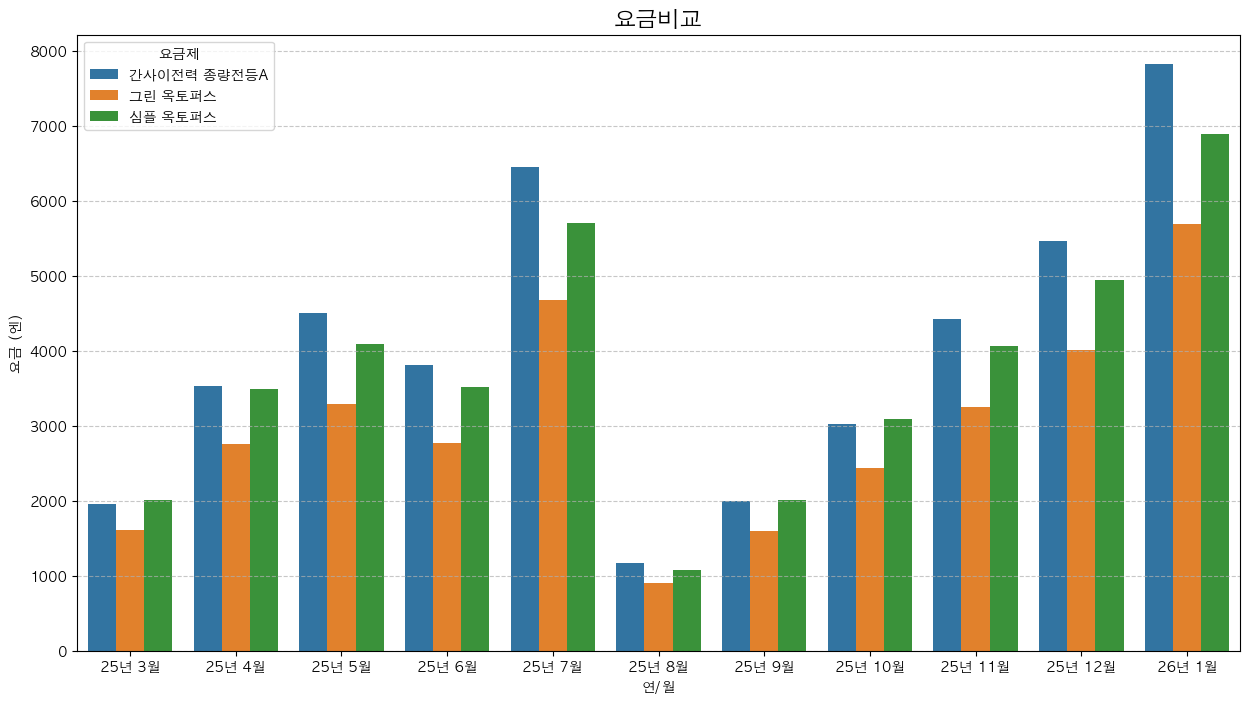

In [19]:
plt.figure(figsize=(15, 8))

ax = sns.barplot(data=df_compare, x='연/월', y='금액', hue='요금제')

plt.title("요금비교", fontsize=16)
plt.ylabel("요금 (엔)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

위 그래프를 통해 간사이 전력에서 옥토퍼스 에너지로 변경함이 무조건 이득임을 알 수 있다. 비교에 사용된 두 가지 요금제 중 '심플 옥토퍼스'는 전력소비량이 적은 달의 경우 간사이전력 종량전등A 요금제와 가격이 거의 차이가 나지 않거나 간혹 더 비싼 경우도 있었다. 그러나 '그린 옥토퍼스'의 경우 일관되게 낮은 가격을 보였다.

In [20]:
sum_dict = {
    "간사이전력 종량전등A" : df['간사이전력 종량전등A'].sum(),
    "그린 옥토퍼스" : df['그린 옥토퍼스'].sum(),
    "심플 옥토퍼스" : df['심플 옥토퍼스'].sum()
}

sum_df = pd.Series(sum_dict).to_frame(name='연간 총 합계 (엔)')

In [21]:
sum_df

,연간 총 합계 (엔)
간사이전력 종량전등A,44137.0
그린 옥토퍼스,32992.2
심플 옥토퍼스,40867.2


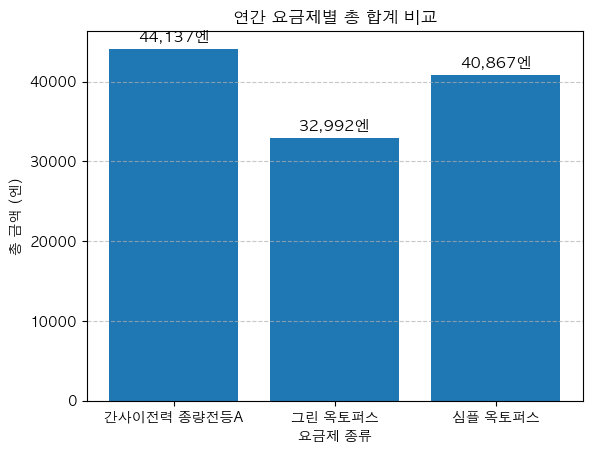

In [22]:
plt.figure()
bars = plt.bar(sum_df.index, sum_df["연간 총 합계 (엔)"])

plt.title('연간 요금제별 총 합계 비교')
plt.ylabel('총 금액 (엔)')
plt.xlabel('요금제 종류')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}엔', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

plt.show()

In [23]:
base_total = sum_df.loc['간사이전력 종량전등A', '연간 총 합계 (엔)']
sum_df['절감액 (엔)'] = base_total - sum_df['연간 총 합계 (엔)']

print(sum_df)

             연간 총 합계 (엔)  절감액 (엔)
간사이전력 종량전등A      44137.0      0.0
그린 옥토퍼스          32992.2  11144.8
심플 옥토퍼스          40867.2   3269.8


위를 보았을 때 '그린 옥토퍼스' 요금제를 사용하는 것이 연간 약 11140엔을 절약할 수 있고 가장 유리한 요금제이다.

## 시뮬레이션 2: 나경

In [24]:
df2 = pd.read_csv("electricity_usage2.csv")

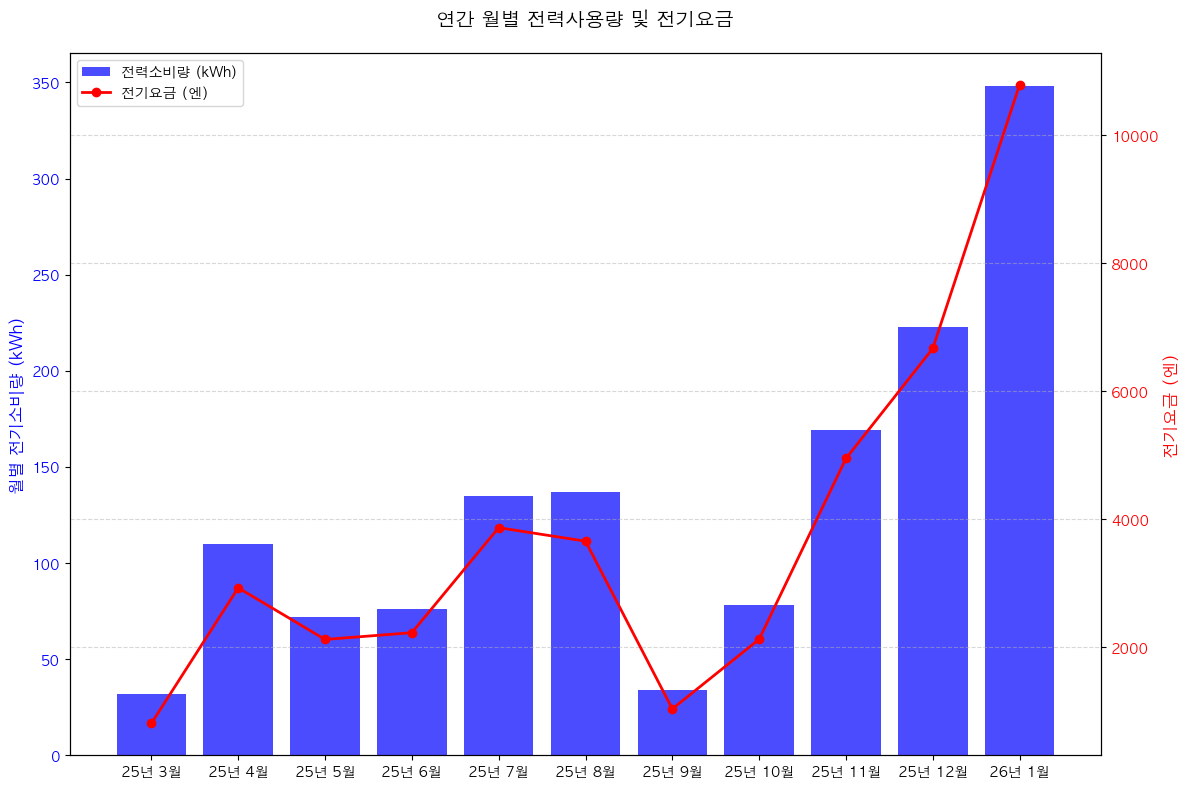

In [28]:
fig, ax1 = plt.subplots(figsize=(12, 8))
plt.title("연간 월별 전력사용량 및 전기요금", fontsize=14, pad=20)

bars = ax1.bar(df2.index, df2["전기사용량"], color="blue", alpha=0.7, label="전력소비량 (kWh)")
ax1.set_ylabel('월별 전기소비량 (kWh)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
line = ax2.plot(df2.index, df2["간사이전력 종량전등A"], color="red", marker='o', linewidth=2, label="전기요금 (엔)")
ax2.set_ylabel('전기요금 (엔)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.xticks(df.index, df2["연/월"], rotation=90)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
df2['그린 옥토퍼스'] = df2.apply(green_octopus, axis=1)
df2['심플 옥토퍼스'] = df2.apply(simple_octopus, axis=1)

In [30]:
df2

,연/월,전기사용량,간사이전력 종량전등A,그린 옥토퍼스,심플 옥토퍼스
0,25년 3월,32,810,725.76,844.8
1,25년 4월,110,2928,2279.60,2904.0
2,25년 5월,72,2121,1528.96,1900.8
3,25년 6월,76,2227,1596.88,2006.4
4,25년 7월,135,3868,2833.30,3564.0
5,25년 8월,137,3657,2878.70,3616.8
6,25년 9월,34,1036,753.52,897.6
7,25년 10월,78,2124,1649.44,2059.2
8,25년 11월,169,4950,3592.70,4461.6
9,25년 12월,223,6669,4830.90,5887.2


In [31]:
df2_compare = df2.melt(id_vars='연/월', 
                     value_vars=['간사이전력 종량전등A', '그린 옥토퍼스', '심플 옥토퍼스'], 
                     var_name='요금제', 
                     value_name='금액')

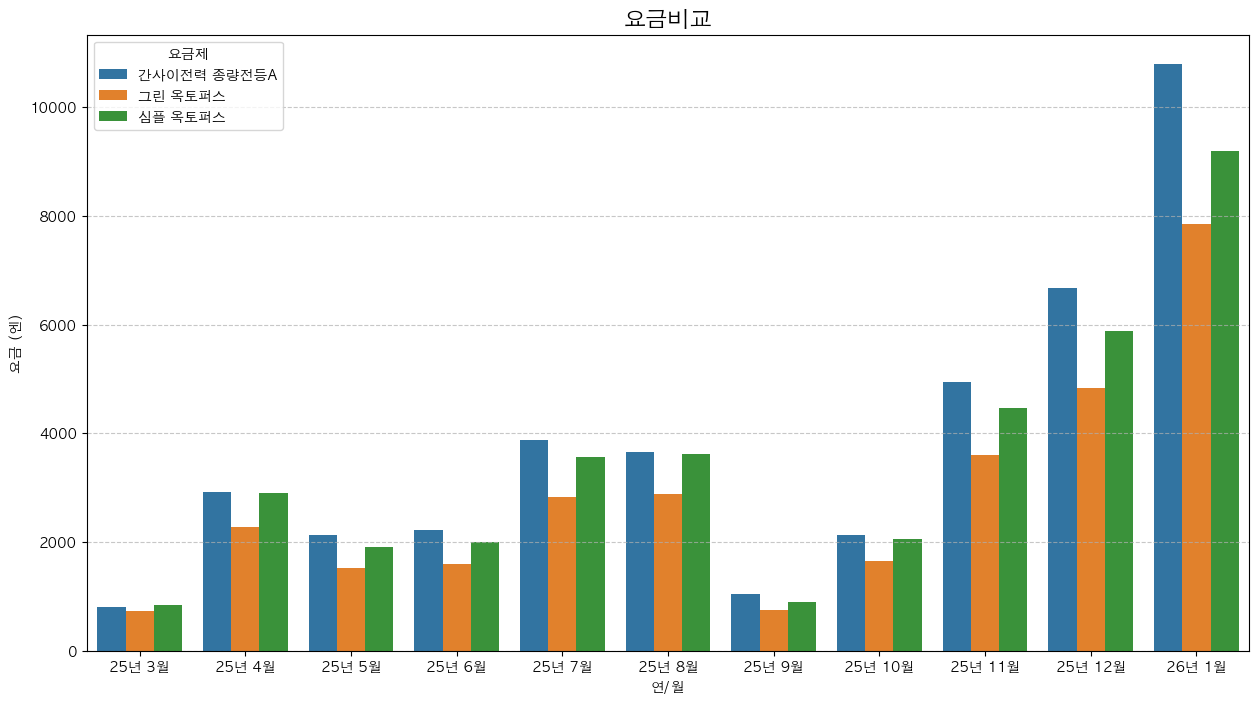

In [32]:
plt.figure(figsize=(15, 8))

ax = sns.barplot(data=df2_compare, x='연/월', y='금액', hue='요금제')

plt.title("요금비교", fontsize=16)
plt.ylabel("요금 (엔)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [33]:
sum_dict2 = {
    "간사이전력 종량전등A" : df2['간사이전력 종량전등A'].sum(),
    "그린 옥토퍼스" : df2['그린 옥토퍼스'].sum(),
    "심플 옥토퍼스" : df2['심플 옥토퍼스'].sum()
}

sum_df2 = pd.Series(sum_dict2).to_frame(name='연간 총 합계 (엔)')

In [34]:
sum_df2

,연간 총 합계 (엔)
간사이전력 종량전등A,41181.00
그린 옥토퍼스,30525.84
심플 옥토퍼스,37329.60


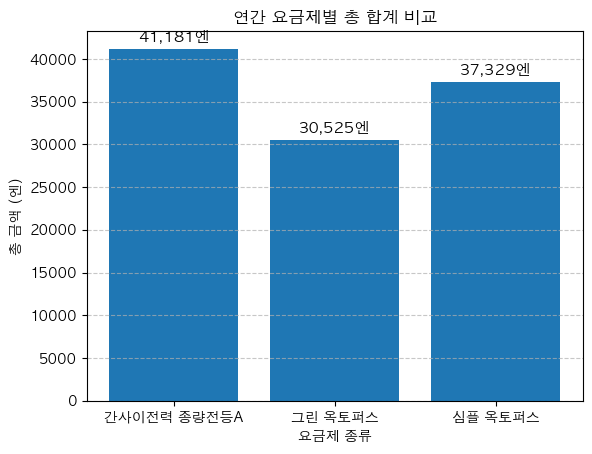

In [35]:
plt.figure()
bars = plt.bar(sum_df2.index, sum_df2["연간 총 합계 (엔)"])

plt.title('연간 요금제별 총 합계 비교')
plt.ylabel('총 금액 (엔)')
plt.xlabel('요금제 종류')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}엔', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

plt.show()

In [37]:
base_total2 = sum_df2.loc['간사이전력 종량전등A', '연간 총 합계 (엔)']
sum_df2['절감액 (엔)'] = base_total2 - sum_df2['연간 총 합계 (엔)']

print(sum_df2)

             연간 총 합계 (엔)   절감액 (엔)
간사이전력 종량전등A     41181.00      0.00
그린 옥토퍼스         30525.84  10655.16
심플 옥토퍼스         37329.60   3851.40


이 경우에도 그린 옥토퍼스가 가장 유리함을 알 수 있다.